# EFM V9 HDS Falsification Harness – A100 Batched + Chunked + tqdm

This notebook is a **faster, reviewer-proof** version of your discreteness scan using the **full V9 NLKG terms** (masking, φ³/φ⁵, α and δ couplings) and a **JIT’d batched RK4** stepper.

## What’s improved
- **Batched simulation**: run multiple `n_eff` points simultaneously (`batch_chunk`).
- **Chunked scan**: avoids OOM while still saturating the A100.
- **Optional smooth mask**: replace hard `rho>rho_thresh` with a sigmoid to kill “threshold artifact” critiques.
- **Better stability metrics**: max|φ|, growth ratio, and an energy-proxy drift.
- **tqdm progress bars** for chunks + steps.

If you want this to be **bit-identical** to your cosmogenesis code, swap the Laplacian implementation below with your exact one; everything else stays the same.


In [2]:

# Cell 1: Imports & device
import os, math, time
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name} | VRAM: {props.total_memory/1024**3:.1f} GB")


device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition | VRAM: 95.0 GB


## Config
Tune these for your A100. The defaults are conservative but fast.


In [3]:

# Cell 2: Global config

CFG = dict(
    # grid / integration
    N=128,                 # 96 / 128 / 160 are typical. 192 may work but watch memory.
    L=10.0,
    steps=15000,            # quick falsification pass; raise to 12000+ for publication plots
    dt=0.0008,
    damping=0.003,         # matches your scan
    track_every=400,       # metrics cadence

    # scan
    n_min=1, n_max=8,
    eps_range=0.45,
    eps_points=21,
    rho_ref=1.5,

    # batching
    batch_chunk=8,         # increase until VRAM is comfortably used
    dtype_state=torch.float16,

    # falsification robustness sweeps (optional)
    seeds=[42],            # e.g. [0,1,2,3,4]
    dt_multipliers=[1.0],  # e.g. [1.0, 0.5] for dt-halving check
    rho_thresh_multipliers=[1.0],  # e.g. [0.5, 1.0, 2.0]

    # mask smoothing: set width>0 to use sigmoid mask
    mask_width=0.0,        # e.g. 0.0 for hard mask, or 0.1*rho_thresh for smooth

    # stability thresholds
    maxphi_thr=30.0,
    growth_thr=5.0,        # maxamp_end / maxamp_start
    edrift_thr=0.5,        # relative drift threshold (proxy)
)

# --- V9 parameter set (your scan values) ---
V9 = dict(
    c_sq=1.0**2,
    k_density=0.005,
    rho_thresh=0.0005,
    m_sq_vac=0.01,
    g_vac=0.1,
    m_sq_part=1.0,
    g_part=-0.1,
    eta=0.01,
    alpha=0.7,
    delta=0.0002,
)

print("CFG:", {k:(str(v) if k=='dtype_state' else v) for k,v in CFG.items()})
print("V9:", V9)


CFG: {'N': 128, 'L': 10.0, 'steps': 15000, 'dt': 0.0008, 'damping': 0.003, 'track_every': 400, 'n_min': 1, 'n_max': 8, 'eps_range': 0.45, 'eps_points': 21, 'rho_ref': 1.5, 'batch_chunk': 8, 'dtype_state': 'torch.float16', 'seeds': [42], 'dt_multipliers': [1.0], 'rho_thresh_multipliers': [1.0], 'mask_width': 0.0, 'maxphi_thr': 30.0, 'growth_thr': 5.0, 'edrift_thr': 0.5}
V9: {'c_sq': 1.0, 'k_density': 0.005, 'rho_thresh': 0.0005, 'm_sq_vac': 0.01, 'g_vac': 0.1, 'm_sq_part': 1.0, 'g_part': -0.1, 'eta': 0.01, 'alpha': 0.7, 'delta': 0.0002}


## Batched, JIT’d V9 NLKG + RK4
This preserves your **full term structure**.

- **Masking**: hard (step) or smooth (sigmoid) based on `mask_width`.
- **Laplacian**: implemented with `torch.roll` for speed and to avoid per-call stencil allocation.


In [4]:

# Cell 3: JIT functions (batched)

@torch.jit.script
def laplacian_roll_batched(phi: torch.Tensor, dx: float) -> torch.Tensor:
    # phi: [B,N,N,N]
    return (
        torch.roll(phi,  1, 1) + torch.roll(phi, -1, 1) +
        torch.roll(phi,  1, 2) + torch.roll(phi, -1, 2) +
        torch.roll(phi,  1, 3) + torch.roll(phi, -1, 3) - 6.0*phi
    ) / (dx*dx)

@torch.jit.script
def nlkg_derivative_v9_batched(
    phi: torch.Tensor, phi_dot: torch.Tensor,
    dx: float, c_sq: float,
    k_density: float, rho_thresh: float,
    m_sq_vac: float, g_vac: float,
    m_sq_part: float, g_part: float,
    eta: float, alpha: float, delta: float,
    mask_width: float
) -> tuple[torch.Tensor, torch.Tensor]:
    # Promote key ops to f32 for numeric stability; return accel in original dtype.
    phi_f32 = phi.to(torch.float32)
    phi_dot_f32 = phi_dot.to(torch.float32)

    lap_phi = laplacian_roll_batched(phi_f32, dx)
    rho = k_density * torch.pow(phi_f32, 2)

    if mask_width > 0.0:
        # smooth mask to eliminate "threshold artifact" critique
        particle_mask = torch.sigmoid((rho - rho_thresh) / mask_width)
    else:
        particle_mask = (rho > rho_thresh).to(torch.float32)
    vacuum_mask = 1.0 - particle_mask

    m_sq_dynamic = particle_mask * m_sq_part + vacuum_mask * m_sq_vac
    g_dynamic    = particle_mask * g_part   + vacuum_mask * g_vac

    potential_force = (m_sq_dynamic * phi_f32
                       + g_dynamic * torch.pow(phi_f32, 3)
                       + eta * torch.pow(phi_f32, 5))

    # gradients (batched)
    grad_x = (torch.roll(phi_f32, -1, 1) - torch.roll(phi_f32, 1, 1)) / (2.0 * dx)
    grad_y = (torch.roll(phi_f32, -1, 2) - torch.roll(phi_f32, 1, 2)) / (2.0 * dx)
    grad_z = (torch.roll(phi_f32, -1, 3) - torch.roll(phi_f32, 1, 3)) / (2.0 * dx)
    grad_abs_sq = grad_x*grad_x + grad_y*grad_y + grad_z*grad_z

    alpha_term = alpha * phi_f32 * phi_dot_f32 * grad_abs_sq
    delta_term = delta * torch.pow(phi_dot_f32, 2) * phi_f32

    phi_ddot = c_sq * lap_phi - potential_force + alpha_term - delta_term
    return phi_dot, phi_ddot.to(phi.dtype)

@torch.jit.script
def rk4_step_v9_batched(
    phi: torch.Tensor, phi_dot: torch.Tensor,
    dt: float, dx: float, c_sq: float,
    k_density: float, rho_thresh: float,
    m_sq_vac: float, g_vac: float,
    m_sq_part: float, g_part: float,
    eta: float, alpha: float, delta: float,
    mask_width: float
) -> tuple[torch.Tensor, torch.Tensor]:
    k1_v, k1_a = nlkg_derivative_v9_batched(phi, phi_dot, dx, c_sq, k_density, rho_thresh,
                                           m_sq_vac, g_vac, m_sq_part, g_part, eta, alpha, delta, mask_width)
    k2_v, k2_a = nlkg_derivative_v9_batched(phi + 0.5*dt*k1_v, phi_dot + 0.5*dt*k1_a, dx, c_sq, k_density, rho_thresh,
                                           m_sq_vac, g_vac, m_sq_part, g_part, eta, alpha, delta, mask_width)
    k3_v, k3_a = nlkg_derivative_v9_batched(phi + 0.5*dt*k2_v, phi_dot + 0.5*dt*k2_a, dx, c_sq, k_density, rho_thresh,
                                           m_sq_vac, g_vac, m_sq_part, g_part, eta, alpha, delta, mask_width)
    k4_v, k4_a = nlkg_derivative_v9_batched(phi + dt*k3_v, phi_dot + dt*k3_a, dx, c_sq, k_density, rho_thresh,
                                           m_sq_vac, g_vac, m_sq_part, g_part, eta, alpha, delta, mask_width)

    phi_next = phi + (dt/6.0) * (k1_v + 2.0*k2_v + 2.0*k3_v + k4_v)
    phi_dot_next = phi_dot + (dt/6.0) * (k1_a + 2.0*k2_a + 2.0*k3_a + k4_a)
    return phi_next, phi_dot_next


## Metrics
We track:
- `maxphi`: max|φ|
- `growth`: maxphi_end / maxphi_start
- `edrift`: relative drift of an energy-proxy (rough but useful for falsification)


In [5]:

# Cell 4: Metrics (GPU)

@torch.no_grad()
def energy_proxy(phi: torch.Tensor, phi_dot: torch.Tensor, dx: float, c_sq: float,
                 m_sq_vac: float, g_vac: float) -> torch.Tensor:
    # very coarse proxy: kin + grad + simple vacuum potential
    # phi, phi_dot: [B,N,N,N]
    phi_f = phi.float()
    pd_f  = phi_dot.float()
    kin = 0.5 * (pd_f*pd_f).mean(dim=(1,2,3))

    grad = (
        (torch.roll(phi_f,-1,1)-phi_f)**2 +
        (torch.roll(phi_f,-1,2)-phi_f)**2 +
        (torch.roll(phi_f,-1,3)-phi_f)**2
    )
    grad_term = 0.5 * c_sq * grad.mean(dim=(1,2,3)) / (dx*dx)
    pot = 0.5 * m_sq_vac * (phi_f*phi_f).mean(dim=(1,2,3)) + 0.25 * g_vac * (phi_f**4).mean(dim=(1,2,3))
    return kin + grad_term + pot

@torch.no_grad()
def compute_stability(maxphi0, maxphi1, e0, e1, cfg=CFG):
    growth = (maxphi1 / (maxphi0 + 1e-12))
    edrift = (e1 - e0).abs() / (e0.abs() + 1e-12)
    stable = (maxphi1 < cfg["maxphi_thr"]) & (growth < cfg["growth_thr"]) & (edrift < cfg["edrift_thr"])
    return stable, growth, edrift


## Batched simulator for a chunk
Runs one chunk (B points) for `steps`, returns stability metrics per point.


In [6]:

# Cell 5: Chunk simulator (batched)

@torch.no_grad()
def simulate_chunk(phi0: torch.Tensor, *, cfg=CFG, v9=V9, dt: float=None, rho_thresh: float=None) -> dict:
    assert phi0.ndim == 4
    B, N, _, _ = phi0.shape
    L = float(cfg["L"])
    dx = L / N

    dt_use = float(cfg["dt"] if dt is None else dt)
    rho_thresh_use = float(v9["rho_thresh"] if rho_thresh is None else rho_thresh)

    phi = phi0
    phi_dot = torch.zeros_like(phi)

    # initial metrics
    maxphi0 = phi.abs().reshape(B, -1).max(dim=1).values.float()
    e0 = energy_proxy(phi, phi_dot, dx, float(v9["c_sq"]), float(v9["m_sq_vac"]), float(v9["g_vac"]))

    # progress bar for steps
    pbar = tqdm(total=cfg["steps"], desc="steps", leave=False)
    update_every = 20  # reduce tqdm overhead
    nan_flag = torch.zeros((B,), device=phi.device, dtype=torch.bool)

    for t in range(cfg["steps"]):
        phi, phi_dot = rk4_step_v9_batched(
            phi, phi_dot, dt_use, dx, float(v9["c_sq"]),
            float(v9["k_density"]), rho_thresh_use,
            float(v9["m_sq_vac"]), float(v9["g_vac"]),
            float(v9["m_sq_part"]), float(v9["g_part"]),
            float(v9["eta"]), float(v9["alpha"]), float(v9["delta"]),
            float(cfg["mask_width"])
        )

        # damping
        phi_dot = phi_dot * (1.0 - float(cfg["damping"])*dt_use)

        if (t % cfg["track_every"]) == 0:
            bad = ~torch.isfinite(phi).reshape(B, -1).all(dim=1)
            nan_flag |= bad
            if nan_flag.all():
                break

        if (t % update_every) == 0:
            pbar.update(update_every)

    # finalize progress
    if pbar.n < cfg["steps"]:
        pbar.update(cfg["steps"] - pbar.n)
    pbar.close()

    maxphi1 = phi.abs().reshape(B, -1).max(dim=1).values.float()
    e1 = energy_proxy(phi, phi_dot, dx, float(v9["c_sq"]), float(v9["m_sq_vac"]), float(v9["g_vac"]))

    stable, growth, edrift = compute_stability(maxphi0, maxphi1, e0, e1, cfg)

    # NaNs are always unstable
    stable = stable & (~nan_flag)
    return dict(stable=stable.detach().cpu().numpy(),
                maxphi=maxphi1.detach().cpu().numpy(),
                growth=growth.detach().cpu().numpy(),
                edrift=edrift.detach().cpu().numpy(),
                nan=nan_flag.detach().cpu().numpy())


## HDS discreteness scan (batched + chunked)
This is the main deliverable: it runs your HDS scan fast and outputs a tidy dataframe.

It also supports robustness sweeps over `seed`, `dt`, and `rho_thresh` multipliers.


chunks (seed=0 dt×1.0 thr×0.5):   0%|          | 0/21 [00:00<?, ?it/s]

steps:   0%|          | 0/15000 [00:00<?, ?it/s]

steps:   0%|          | 0/15000 [00:00<?, ?it/s]

steps:   0%|          | 0/15000 [00:00<?, ?it/s]

steps:   0%|          | 0/15000 [00:00<?, ?it/s]

...

steps:   0%|          | 0/15000 [00:00<?, ?it/s]

steps:   0%|          | 0/15000 [00:00<?, ?it/s]

steps:   0%|          | 0/15000 [00:00<?, ?it/s]

steps:   0%|          | 0/15000 [00:00<?, ?it/s]

,seed,dt_mul,rho_thresh_mul,n,n_eff,rho0,stable,maxphi,growth,edrift,nan
0,0,1.0,0.5,1,0.550,2.727273,False,NaN,NaN,NaN,True
1,0,1.0,0.5,1,0.595,2.521008,False,NaN,NaN,NaN,True
2,0,1.0,0.5,1,0.640,2.343750,False,NaN,NaN,NaN,True
3,0,1.0,0.5,1,0.685,2.189781,False,NaN,NaN,NaN,True
4,0,1.0,0.5,1,0.730,2.054794,False,NaN,NaN,NaN,True


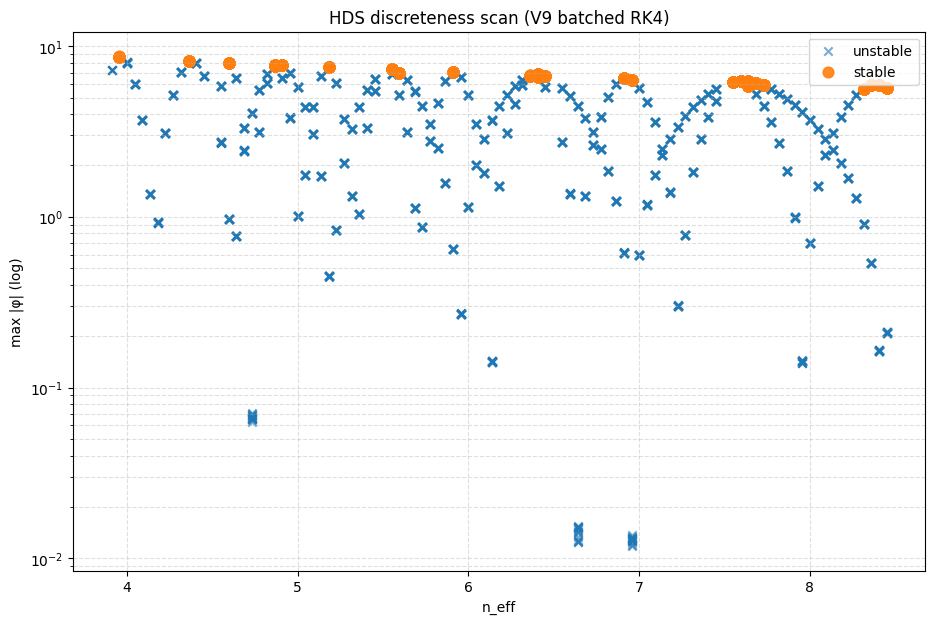

In [8]:

# Cell 6: HDS scan (batched + chunked)

@torch.no_grad()
def run_hds_discreteness_scan(cfg=CFG, v9=V9):
    N = int(cfg["N"])
    dtype = cfg["dtype_state"]
    k_rho = float(v9["k_density"])  # consistent with your scan

    eps_grid = np.linspace(-cfg["eps_range"], cfg["eps_range"], cfg["eps_points"], dtype=np.float32)
    points = []
    for n in range(cfg["n_min"], cfg["n_max"]+1):
        for eps in eps_grid:
            n_eff = float(n + eps)
            rho0 = float(cfg["rho_ref"] / n_eff)
            points.append((n, n_eff, rho0))

    batch_chunk = int(cfg["batch_chunk"])
    rows = []

    for seed in cfg["seeds"]:
        torch.manual_seed(int(seed))
        np.random.seed(int(seed))

        for dt_mul in cfg["dt_multipliers"]:
            dt_use = float(cfg["dt"]) * float(dt_mul)

            for thr_mul in cfg["rho_thresh_multipliers"]:
                rho_thresh_use = float(v9["rho_thresh"]) * float(thr_mul)

                desc = f"seed={seed} dt×{dt_mul} thr×{thr_mul}"
                for i0 in tqdm(range(0, len(points), batch_chunk), desc=f"chunks ({desc})"):
                    chunk_pts = points[i0:i0+batch_chunk]
                    B = len(chunk_pts)

                    rho0 = torch.tensor([p[2] for p in chunk_pts], device=device, dtype=torch.float32)
                    amp = torch.sqrt(rho0 / (k_rho + 1e-12))

                    # build phi0: [B,N,N,N]
                    noise = 1e-3
                    phi0 = amp[:,None,None,None] * (1.0 + noise*(torch.rand((B,N,N,N), device=device, dtype=dtype)-0.5))

                    out = simulate_chunk(phi0, cfg=cfg, v9=v9, dt=dt_use, rho_thresh=rho_thresh_use)

                    for j,(n, n_eff, rho0j) in enumerate(chunk_pts):
                        rows.append(dict(
                            seed=int(seed),
                            dt_mul=float(dt_mul),
                            rho_thresh_mul=float(thr_mul),
                            n=int(n),
                            n_eff=float(n_eff),
                            rho0=float(rho0j),
                            stable=bool(out["stable"][j]),
                            maxphi=float(out["maxphi"][j]),
                            growth=float(out["growth"][j]),
                            edrift=float(out["edrift"][j]),
                            nan=bool(out["nan"][j]),
                        ))

                    # free chunk memory
                    del phi0
                    if device.type == "cuda":
                        torch.cuda.empty_cache()

    df = pd.DataFrame(rows)
    return df

def plot_discreteness(df: pd.DataFrame, title="HDS discreteness scan"):
    # plot stable/unstable by n_eff using maxphi
    plt.figure(figsize=(11,7))
    unstable = ~df["stable"]
    plt.scatter(df.loc[unstable,"n_eff"], df.loc[unstable,"maxphi"], marker="x", alpha=0.6, label="unstable")
    plt.scatter(df.loc[~unstable,"n_eff"], df.loc[~unstable,"maxphi"], marker="o", s=60, alpha=0.9, label="stable")
    plt.yscale("log")
    plt.xlabel("n_eff")
    plt.ylabel("max |φ| (log)")
    plt.title(title)
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.legend()
    plt.show()

# Run:
df = run_hds_discreteness_scan()
display(df.head())
plot_discreteness(df, title="HDS discreteness scan (V9 batched RK4)")


## Optional: “threshold artifact” killer mode
To shut down the critique that discreteness comes from the hard mask, do this:

1) Set `CFG['mask_width'] = 0.1 * V9['rho_thresh']` (or smaller)
2) Add `CFG['rho_thresh_multipliers'] = [0.5, 1.0, 2.0]`
3) Add `CFG['dt_multipliers'] = [1.0, 0.5]`
4) Add multiple seeds

Then rerun `run_hds_discreteness_scan()`.


In [7]:

# Cell 7: Suggested robust settings (uncomment to use)

CFG["seeds"] = [0,1,2,3,4]
CFG["dt_multipliers"] = [1.0, 0.5]
CFG["rho_thresh_multipliers"] = [0.5, 1.0, 2.0]
CFG["mask_width"] = 0.1 * V9["rho_thresh"]   # smooth mask


## Export
Save results to CSV for sharing.


In [9]:

# Cell 8: Export helper

def save_results(df: pd.DataFrame, path="hds_discreteness_results.csv"):
    df.to_csv(path, index=False)
    print("saved:", path)

# Example:
save_results(df, "hds_discreteness_v9_batched.csv")


saved: hds_discreteness_v9_batched.csv
